<a href="https://www.kaggle.com/code/remy2017/feature-engineering-creating-features?scriptVersionId=311241423" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

This notebook is similar to the section "Creating Features" of the course "Feature Enginerring"; However, it uses  exclusively the dataset "US_Accidents_March23.csv" instead of using several datasets in the original notebok.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sobhanmoosavi/us-accidents/US_Accidents_March23.csv


In [2]:
# import dataset(s) into pandas and print samples.

fpath = '/kaggle/input/datasets/sobhanmoosavi/us-accidents/US_Accidents_March23.csv'
accidents = pd.read_csv(fpath, nrows=1000000)
pd.set_option('display.max_columns', None)
# Print sample rows
accidents.head(5)

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,Right lane blocked due to accident on I-70 Eas...,I-70 E,Dayton,Montgomery,OH,45424,US,US/Eastern,KFFO,2016-02-08 05:58:00,36.9,NaN,91.0,29.68,10.0,Calm,NaN,0.02,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,Accident on Brice Rd at Tussing Rd. Expect del...,Brice Rd,Reynoldsburg,Franklin,OH,43068-3402,US,US/Eastern,KCMH,2016-02-08 05:51:00,37.9,NaN,100.0,29.65,10.0,Calm,NaN,0.00,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,Accident on OH-32 State Route 32 Westbound at ...,State Route 32,Williamsburg,Clermont,OH,45176,US,US/Eastern,KI69,2016-02-08 06:56:00,36.0,33.3,100.0,29.67,10.0,SW,3.5,NaN,Overcast,False,False,False,False,False,False,False,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,Accident on I-75 Southbound at Exits 52 52B US...,I-75 S,Dayton,Montgomery,OH,45417,US,US/Eastern,KDAY,2016-02-08 07:38:00,35.1,31.0,96.0,29.64,9.0,SW,4.6,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,Accident on McEwen Rd at OH-725 Miamisburg Cen...,Miamisburg Centerville Rd,Dayton,Montgomery,OH,45459,US,US/Eastern,KMGY,2016-02-08 07:53:00,36.0,33.3,89.0,29.65,6.0,SW,3.5,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day


In [3]:
accidents.shape

(1000000, 46)

In [4]:
accidents.dtypes

ID                        object
Source                    object
Severity                   int64
Start_Time                object
End_Time                  object
Start_Lat                float64
Start_Lng                float64
End_Lat                  float64
End_Lng                  float64
Distance(mi)             float64
Description               object
Street                    object
City                      object
County                    object
State                     object
Zipcode                   object
Country                   object
Timezone                  object
Airport_Code              object
Weather_Timestamp         object
Temperature(F)           float64
Wind_Chill(F)            float64
Humidity(%)              float64
Pressure(in)             float64
Visibility(mi)           float64
Wind_Direction            object
Wind_Speed(mph)          float64
Precipitation(in)        float64
Weather_Condition         object
Amenity                     bool
Bump      

## **Mathematical Transformations**

In [5]:
accidents['Wind_Chill(F)']

0          NaN
1          NaN
2         33.3
3         31.0
4         33.3
          ... 
999995    73.0
999996    73.0
999997    79.0
999998    77.0
999999    72.0
Name: Wind_Chill(F), Length: 1000000, dtype: float64

In [6]:
accidents["cold_sensation"] = accidents['Wind_Chill(F)'] / accidents['Temperature(F)'] 

accidents[["Wind_Chill(F)", "Temperature(F)", "cold_sensation" ]].head()

,Wind_Chill(F),Temperature(F),cold_sensation
0,NaN,36.9,NaN
1,NaN,37.9,NaN
2,33.3,36.0,0.925000
3,31.0,35.1,0.883191
4,33.3,36.0,0.925000


## **Normalisation**

Data visualization can suggest transformations, often a "reshaping" of a feature through powers or logarithms. The distribution of WindSpeed in US Accidents is highly skewed, for instance. In this case the logarithm is effective at normalizing it:

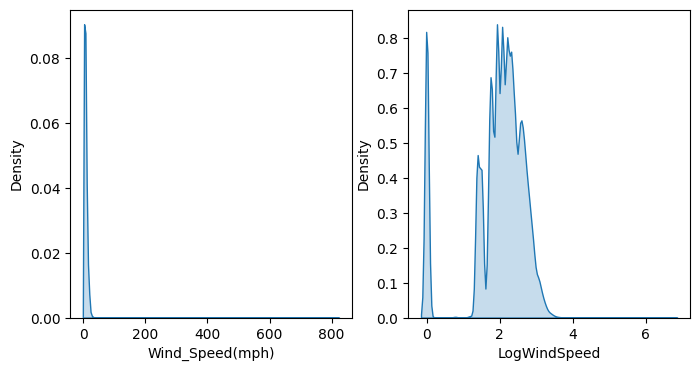

In [7]:
# If the feature has 0.0 values, use np.log1p (log(1+x)) instead of np.log
accidents["LogWindSpeed"] = accidents['Wind_Speed(mph)'].apply(np.log1p)

# Plot a comparison
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
sns.kdeplot(accidents['Wind_Speed(mph)'], fill=True, ax=axs[0])
sns.kdeplot(accidents.LogWindSpeed, fill=True, ax=axs[1]);

### How does it work?

The previous code snippet performs a log transformation on a 'Wind_Speed(mph)' column and then visualizes the distribution of both the original and transformed data. Here's a breakdown:

"If the feature has 0.0 values, use np.log1p (log(1+x)) instead of np.log"

This is a comment explaining a best practice. The np.log function (natural logarithm) is undefined for 0.0. **If your data might contain zeros, np.log1p (which calculates log(1+x)) is safer because log(1+0) is log(1) which is 0, avoiding errors.**

`accidents["LogWindSpeed"] = accidents['Wind_Speed(mph)'].apply(np.log1p)`

A new column named LogWindSpeed is created in your accidents DataFrame.
It's calculated by applying the np.log1p function to each value in the existing Wind_Speed(mph) column.

This effectively transforms the Wind_Speed(mph) data, often to reduce skewness and make the distribution more symmetrical (closer to a normal distribution).

`fig, axs = plt.subplots(1, 2, figsize=(8, 4))`

This line uses matplotlib.pyplot to create a figure (fig) and a set of subplots (axs).
1, 2 means it will create a grid of 1 row and 2 columns for your plots.

`figsize=(8, 4)` sets the total width of the figure to 8 inches and height to 4 inches.

`sns.kdeplot(accidents['Wind_Speed(mph)'], fill=True, ax=axs[0])`

This uses seaborn (aliased as sns) to create a **Kernel Density Estimate (KDE)** plot for the original Wind_Speed(mph) column.
A KDE plot visualizes the probability density function of a continuous variable, showing where the data points are concentrated.

`fill=True` shades the area under the density curve.
`ax=axs[0]` places this plot in the first (left) subplot.

`sns.kdeplot(accidents.LogWindSpeed, fill=True, ax=axs[1])`;

Similarly, this creates a KDE plot for the LogWindSpeed column (the transformed data).
ax=axs[1] places this plot in the second (right) subplot.
In essence, this code transforms wind speed data using a logarithm and then visually compares the distribution of the original and transformed data side-by-side to show the effect of the transformation.

## **Counts**

Features describing the presence or absence of something often come in sets, the set of risk factors for a disease, say. You can aggregate such features by creating a count.

These features will be binary (1 for Present, 0 for Absent) or boolean (True or False). In Python, booleans can be added up just as if they were integers.

In Traffic Accidents are several features indicating whether some roadway object was near the accident. This will create a count of the total number of roadway features nearby using the sum method:

In [8]:
roadway_features = ["Amenity", "Bump", "Crossing", "Give_Way",
    "Junction", "No_Exit", "Railway", "Roundabout", "Station", "Stop",
    "Traffic_Calming", "Traffic_Signal"]
accidents["RoadwayFeatures"] = accidents[roadway_features].sum(axis=1) #sums accross rows (for each row)

accidents[roadway_features + ["RoadwayFeatures"]].head(5)

,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,RoadwayFeatures
0,False,False,False,False,False,False,False,False,False,False,False,False,0
1,False,False,False,False,False,False,False,False,False,False,False,False,0
2,False,False,False,False,False,False,False,False,False,False,False,True,1
3,False,False,False,False,False,False,False,False,False,False,False,False,0
4,False,False,False,False,False,False,False,False,False,False,False,True,1


In [9]:
accidents.columns # the column RoadwaysFeatures has been addedd to the dataframe

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight', 'cold_sensation', 'LogWindSpeed',
       'RoadwayFeatures'],
      dtype='object')

### **Splitting datetime columns**

The idea here is to separate date and time. 

In [10]:
mydate = '2016-02-08 05:46:00'
new_date = mydate.split(" ")
new_date


['2016-02-08', '05:46:00']

In [11]:
from datetime import datetime

accidents[["date", "time"]] = accidents["Start_Time"].str.split(" ", expand=True) #expand the split strngs into separate columns in a new dataframe

accidents[["Start_Time", "date", "time"]].head(5)


,Start_Time,date,time
0,2016-02-08 05:46:00,2016-02-08,05:46:00
1,2016-02-08 06:07:59,2016-02-08,06:07:59
2,2016-02-08 06:49:27,2016-02-08,06:49:27
3,2016-02-08 07:23:34,2016-02-08,07:23:34
4,2016-02-08 07:39:07,2016-02-08,07:39:07


The original column is an object dtype, so the splitted columns will be also an object datatype.

In [12]:
accidents["date"].dtype

dtype('O')

For that reason is better to parse the dates by using the function pd.to_datetime()

In [13]:
# create a new column, date_parsed, with the parsed dates
accidents['date_parsed'] = pd.to_datetime(accidents['Start_Time'], format="%Y-%m-%d %H:%M:%S")

# Then split into two columns
accidents['date_only'] = accidents['date_parsed'].dt.date
accidents['time_only'] = accidents['date_parsed'].dt.time

print(accidents['date_only'].head(5))
print(accidents['time_only'].head(5))

0    2016-02-08
1    2016-02-08
2    2016-02-08
3    2016-02-08
4    2016-02-08
Name: date_only, dtype: object
0    05:46:00
1    06:07:59
2    06:49:27
3    07:23:34
4    07:39:07
Name: time_only, dtype: object


We could also create new components as separate integer columns:

In [14]:
accidents['year']   = accidents['date_parsed'].dt.year
accidents['month']  = accidents['date_parsed'].dt.month
accidents['day']    = accidents['date_parsed'].dt.day
accidents['hour']   = accidents['date_parsed'].dt.hour
accidents['minute'] = accidents['date_parsed'].dt.minute

print(accidents['year'].head(1))
print(accidents['month'].head(1))
print(accidents['day'].head(1))
print(accidents['hour'].head(1))
print(accidents['minute'].head(1))


0    2016
Name: year, dtype: int32
0    2
Name: month, dtype: int32
0    8
Name: day, dtype: int32
0    5
Name: hour, dtype: int32
0    46
Name: minute, dtype: int32


## **Group Transforms**

Finally we have Group transforms, which aggregate information across multiple rows grouped by some category. With a group transform you can create features like: "the average income of a person's state of residence," or "the proportion of movies released on a weekday, by genre." If you had discovered a category interaction, a group transform over that categry could be something good to investigate.

Using an aggregation function, a group transform combines two features: a categorical feature that provides the grouping and another feature whose values you wish to aggregate. For an "average income by state", you would choose State for the grouping feature, mean for the aggregation function, and Income for the aggregated feature. To compute this in Pandas, we use the groupby and transform methods:

In [15]:
accidents["AvgTempCity"] = (
    accidents.groupby("City")  # for each state
    ["Temperature(F)"]         # select the income
    .transform("mean")         # and compute its mean
)

accidents[["City", "Temperature(F)", "AvgTempCity"]].head(10)

,City,Temperature(F),AvgTempCity
0,Dayton,36.9,57.286231
1,Reynoldsburg,37.9,54.427857
2,Williamsburg,36.0,62.275897
3,Dayton,35.1,57.286231
4,Dayton,36.0,57.286231
5,Westerville,37.9,56.887288
6,Dayton,34.0,57.286231
7,Dayton,34.0,57.286231
8,Dayton,33.3,57.286231
9,Westerville,37.4,56.887288


The mean function is a built-in dataframe method, which means we can pass it as a string to transform. Other handy methods include max, min, median, var, std, and count. Here's how you could calculate the frequency with which each city occurs in the dataset:

In [16]:
accidents["CityFreq"] = (
    accidents.groupby("City")  
    ["City"]                 
    .transform("count") / accidents.City.count()        
)

accidents[["City", "CityFreq"]].head(10)

,City,CityFreq
0,Dayton,0.007730
1,Reynoldsburg,0.000140
2,Williamsburg,0.000206
3,Dayton,0.007730
4,Dayton,0.007730
5,Westerville,0.000236
6,Dayton,0.007730
7,Dayton,0.007730
8,Dayton,0.007730
9,Westerville,0.000236


#### Frequency Encoding

You could use a transform like this to create a "frequency encoding" for a categorical feature. This code creates an average temperature per US state as a new feature. Instead of using the raw "State" category (e.g. "CA", "TX"), each row gets replaced with a meaningful number — the average temperature recorded in accidents for that state

If you're using training and validation splits, to preserve their independence, it's best to create a grouped feature using only the training set and then join it to the validation set. We can use the validation set's merge method after creating a unique set of values with drop_duplicates on the training set:

In [17]:
# Create splits
df_train = accidents.sample(frac=0.5)
df_valid = accidents.drop(df_train.index)

# Create the average claim amount by coverage type, on the training set
df_train["AvgTempState"] = df_train.groupby("State")["Temperature(F)"].transform("mean")

# Merge the values into the validation set
df_valid = df_valid.merge(
    df_train[["State", "AvgTempState"]].drop_duplicates(),
    on="State",
    how="left",
)

df_valid[["State", "AvgTempState"]].tail(10)

,State,AvgTempState
499990,FL,75.012569
499991,FL,75.012569
499992,FL,75.012569
499993,FL,75.012569
499994,FL,75.012569
499995,FL,75.012569
499996,FL,75.012569
499997,FL,75.012569
499998,FL,75.012569
499999,FL,75.012569


### How does it work?

The code is creating a frequency/target encoding — replacing a categorical value with a meaningful number (the average temperature by State). This helps ML models that can't work with raw categories.

1. Split the data

    `df_train = accidents.sample(frac=0.5)`

    `df_valid = accidents.drop(df_train.index)`

You split before computing anything. The rule is: the validation set must never influence what your model learns. If you computed averages on the full dataset and then split, your validation set would have "leaked" information into the training stats — making your model look better than it really is.

2. Compute the average temperature per state (training only)
   
    `df_train["AvgTempState"] = df_train.groupby("State")["Temperature(F)"].transform("mean")`

    `groupby("State")` — groups all rows by their state (e.g. all California accidents together)

    `["Temperature(F)"].transform("mean")` — each row gets the mean temperature of its state's group

So if California accidents recorded temps of 60°F, 70°F, 80°F, every California row gets AvgTempState = 70. The dataframe keeps the same number of rows.

3. Build a lookup table and merge onto validation

    `df_valid = df_valid.merge(
    df_train[["State", "AvgTempState"]].drop_duplicates(),
    on="State",
    how="left",)`

   `df_train[["State", "AvgTempState"]]` — Pull just those two columns.
   `.drop_duplicates()` — Since every CA row has the same AvgTempState, collapse down to one row per state — a clean lookup table.
   `.merge(..., on="State", how="left")` — Match each validation row to its state's average, computed from training.

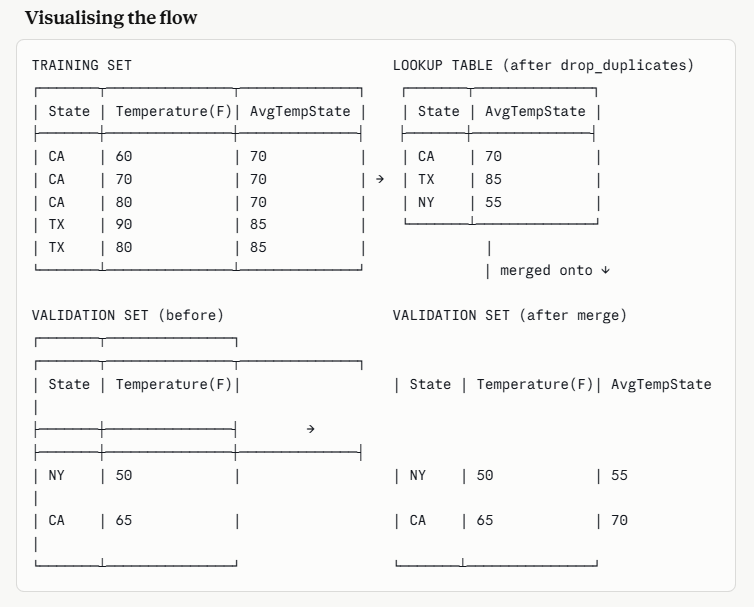
   

Raw state names ("CA", "TX") are just strings — most ML models can't use them directly. By encoding each state as its average accident temperature, you're giving the model a numerical signal that captures something real: states have different typical climates, and that might correlate with accident severity, frequency, or other targets you're trying to predict.

#### The key insight

The validation set never "knows" its own averages — it borrows the averages from training. This is exactly how it would work in production: your model is trained, then later sees new data where you apply the same pre-computed lookup. The validation set is simulating that real-world scenario.